In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../Datasets/delivery_time.csv")
df.head(2)

,distance_km,delivery_time_min
0,7.5,34
1,4.6,25


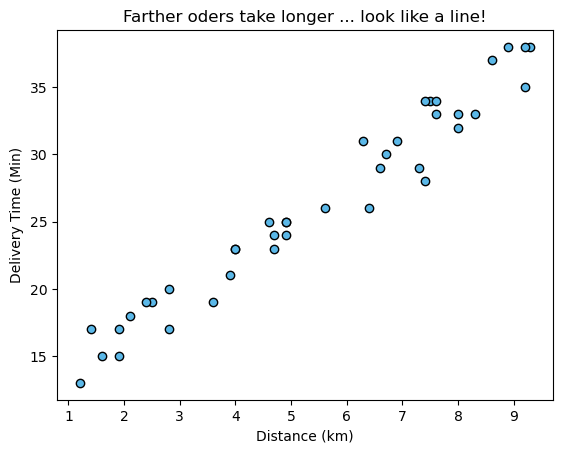

In [11]:
plt.scatter(df.distance_km, df.delivery_time_min, color= '#5BB8E8', edgecolor= 'k')
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Min)")
plt.title("Farther oders take longer ... look like a line!")
plt.show()

In [12]:
#Know we need to draw a best fit line for this we are importing a model from " sklearn "

from sklearn.linear_model import LinearRegression

#we are creating a model out of this
model= LinearRegression()

#know we are fitting a model, here we find best fit line
model.fit(df[['distance_km']], df['delivery_time_min'])

LinearRegression()

In [18]:
#After fit we can see model learned slope (relation between X, y), Intercept (Starting point)

#we can check slope
model.coef_

array([2.81819063])

In [19]:
#Intercept
model.intercept_

10.944042964016218

In [14]:
#Now we are predicting delivery time for 7km and 34km

model.predict([[7], [34]])

C:\Users\Shaik\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 30.67137739, 106.76252444])

In [17]:
#Best way is to predict making it to Data Frame

model.predict(pd.DataFrame({"distance_km": [7, 34]}))

array([ 30.67137739, 106.76252444])

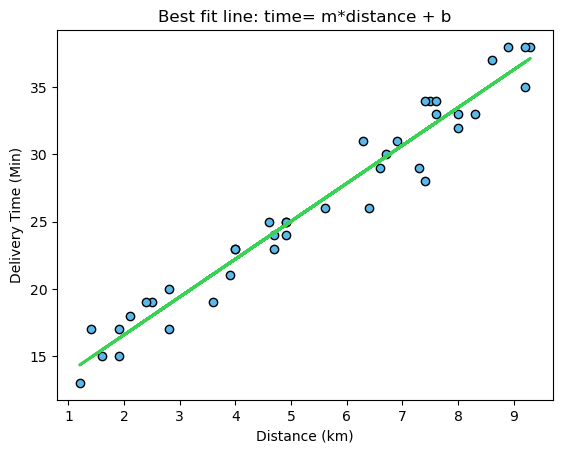

In [24]:
#Drawing best line using matplotlib

plt.scatter(df.distance_km, df.delivery_time_min, color= '#5BB8EB', edgecolor='k')
plt.plot(df.distance_km, model.predict(df[["distance_km"]]), color= '#39D353', linewidth= 2)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Min)")
plt.title("Best fit line: time= m*distance + b")
plt.show()

#### Multi Linear Regression ---> here you will have multiple variables effects your outcome (In this case Rain, Traffic, Road.. affect delivery time)

In [7]:
#reading the data
df2= pd.read_csv("../Datasets/delivery_time_multi.csv")
df2.head(3)

,distance_km,traffic_level,raining,delivery_time_min
0,7.9,5,1,38
1,2.3,10,0,26
2,1.0,2,1,18


In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
model2= LinearRegression()

In [16]:
features= ['distance_km', 'traffic_level', 'raining']

model2.fit(df2[features], df2['delivery_time_min'])

LinearRegression()

In [17]:
#For new order

new_order= pd.DataFrame({'distance_km':[7],
                        'traffic_level':[8],
                        'raining':[1]})
predicted= model2.predict(new_order)

In [18]:
predicted

array([39.80716222])

#### Tain Test Split

In [19]:
#Loading the data

import pandas as pd

df= pd.read_csv("../Datasets/delivery_time_multi.csv")
df.head(3)

,distance_km,traffic_level,raining,delivery_time_min
0,7.9,5,1,38
1,2.3,10,0,26
2,1.0,2,1,18


In [21]:
# I am gonna define our features

features= ['distance_km', 'traffic_level', 'raining']

X= df[features]                    #-->features multiple columns(thats why X)

y= df['delivery_time_min']           #desired value/target variable (y single value)

In [23]:
X.head(3)

,distance_km,traffic_level,raining
0,7.9,5,1
1,2.3,10,0
2,1.0,2,1


In [25]:
X.shape

(60, 3)

In [26]:
y.shape

(60,)

##### In this part we split the data into desired structure, here we have done 80/20

In [58]:
#using trian test split method

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
X_train.head(3)

,distance_km,traffic_level,raining
31,5.8,7,0
3,1.6,6,1
52,5.9,10,0


In [60]:
X_train.shape

(48, 3)

In [61]:
48/60*100    #You can see 80 % data is used in training period

80.0

In [62]:
X_test.shape

(12, 3)

In [63]:
12/60*100    # look 20 is used in testing purpose

20.0

In [64]:
y_train.head(3)

31    31
3     26
52    35
Name: delivery_time_min, dtype: int64

In [65]:
y_train.shape

(48,)

In [66]:
48/60*100

80.0

In [67]:
y_test.shape

(12,)

In [71]:
y_train.head(3)

31    31
3     26
52    35
Name: delivery_time_min, dtype: int64

##### Now we are Training the data with the 80 %

In [68]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

##### We are evaluating the model with rest 20 % data    {what we get here we can't assume " The Model is 95% accurate "}


In [69]:
test_r2= model.score(X_test, y_test)
test_r2

0.8852751875137498

#### We also use R**2 for traing data


In [70]:
train_r2= model.score(X_train, y_train)
train_r2

0.9592110655331624

##### If model.score() is similiar we can say model is doing good(when train and test data are somewhat similar)
If one is low and other one is high this is called "Overfitting" 

If both are low then it means they "Underfitting"